## PyLaunch - Modelling Lead Part

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
ds = pd.read_csv("Dataset_ModellingLead.csv")
ds = ds.drop(['Unnamed: 0'], axis=1)
ds.head(5)

,FL_DATE,DEP_HOUR,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,TAIL_NUM,ORIGIN,DEST,DEP_TIME,...,CLOUD_COVER,ACTIVE_WEATHER,WEATHER_SEVERITY,TEMP_DEW_DIFF,WIND_INTENSITY,VISIBILITY_CATEGORY,HUMIDITY_LEVEL,WIND_DIRECTION,TOTAL_CLOUD,CLOUD_COVER_ENCODED
0,2022-01-01,6,AA,1019,AA,1019,N764US,SJC,DFW,2022-01-01 06:05:00,...,1.0,0.0,7.640,3.89,0.0,Moderate,High,North,1.0,1
1,2022-01-01,7,AA,1025,AA,1025,N572UW,TUS,DFW,2022-01-01 07:26:00,...,4.0,1.0,11.704,1.72,8.0,Moderate,Very High,South,1.0,4
2,2022-01-01,8,AA,1032,AA,1032,N771AN,JFK,MIA,2022-01-01 08:56:00,...,4.0,0.0,11.419,0.50,5.0,Moderate,Very High,East,1.0,4
3,2022-01-01,23,AA,1033,AA,1033,N770UW,CLT,IND,2022-01-01 23:26:00,...,3.0,0.0,11.781,1.72,8.0,Moderate,Very High,South,2.0,3
4,2022-01-01,20,AA,1043,AA,1043,N8009T,CLT,CLE,2022-01-01 20:58:00,...,4.0,0.0,12.949,5.00,16.0,Moderate,High,South,3.0,4


In [4]:
ds.dtypes[ds.dtypes == "int64"]

DEP_HOUR               int64
MKT_CARRIER_FL_NUM     int64
OP_CARRIER_FL_NUM      int64
TAXI_OUT               int64
DEP_DELAY              int64
AIR_TIME               int64
DISTANCE               int64
CANCELLED              int64
ELEVATION              int64
YEAR OF MANUFACTURE    int64
CLOUD_COVER_ENCODED    int64
dtype: object

In [5]:
for i in ds.head(1):
    print(f"{i}: {ds[i].loc[0]}")

FL_DATE: 2022-01-01
DEP_HOUR: 6
MKT_UNIQUE_CARRIER: AA
MKT_CARRIER_FL_NUM: 1019
OP_UNIQUE_CARRIER: AA
OP_CARRIER_FL_NUM: 1019
TAIL_NUM: N764US
ORIGIN: SJC
DEST: DFW
DEP_TIME: 2022-01-01 06:05:00
CRS_DEP_TIME: 2022-01-01 06:10:00
TAXI_OUT: 25
DEP_DELAY: -5
AIR_TIME: 172
DISTANCE: 1438
CANCELLED: 0
LATITUDE: 37.363056
LONGITUDE: -121.92861
ELEVATION: 62
MESONET_STATION: SJC
YEAR OF MANUFACTURE: 2000
MANUFACTURER: Airbus
ICAO TYPE: A319
RANGE: Medium Range
WIDTH: Narrow-body
WIND_DIR: 0.0
WIND_SPD: 0.0
WIND_GUST: 0.0
VISIBILITY: 10.0
TEMPERATURE: 7.78
DEW_POINT: 3.89
REL_HUMIDITY: 76.4
ALTIMETER: 30.02
LOWEST_CLOUD_LAYER: 2000.0
N_CLOUD_LAYER: 1.0
LOW_LEVEL_CLOUD: 1.0
MID_LEVEL_CLOUD: 0.0
HIGH_LEVEL_CLOUD: 0.0
CLOUD_COVER: 1.0
ACTIVE_WEATHER: 0.0
WEATHER_SEVERITY: 7.640000000000001
TEMP_DEW_DIFF: 3.89
WIND_INTENSITY: 0.0
VISIBILITY_CATEGORY: Moderate
HUMIDITY_LEVEL: High
WIND_DIRECTION: North
TOTAL_CLOUD: 1.0
CLOUD_COVER_ENCODED: 1


In [6]:
ds['DEP_TIME']

0          2022-01-01 06:05:00
1          2022-01-01 07:26:00
2          2022-01-01 08:56:00
3          2022-01-01 23:26:00
4          2022-01-01 20:58:00
                  ...         
1615798    2022-12-31 05:36:00
1615799    2022-12-31 20:04:00
1615800    2022-12-31 11:44:00
1615801    2022-12-31 07:58:00
1615802    2022-12-31 05:01:00
Name: DEP_TIME, Length: 1615803, dtype: object

In [7]:
ds['FLIGHT_DELAY'] = np.where((ds['DEP_DELAY'] >= 15) | (ds['CANCELLED'] != 0), 1, 0)

In [8]:
ds['FLIGHT_DELAY'].value_counts()

FLIGHT_DELAY
0    1275826
1     339977
Name: count, dtype: int64

In [9]:
columns_to_drop = ['DEP_TIME', 'CRS_DEP_TIME', 'TAXI_OUT', 'DEP_DELAY', 'AIR_TIME', 'CANCELLED','MKT_CARRIER_FL_NUM','MKT_UNIQUE_CARRIER',
                   'OP_CARRIER_FL_NUM', 'TAIL_NUM', 'FL_DATE', 'MESONET_STATION', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
                    'YEAR OF MANUFACTURE']

In [10]:
clean_ds = ds.drop(columns_to_drop, axis=1)
print(f"Cleaned Dataset Shape : {clean_ds.shape}") # Columns reduced from 48 to 34

Cleaned Dataset Shape : (1615803, 33)


In [11]:
clean_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615803 entries, 0 to 1615802
Data columns (total 33 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   DEP_HOUR             1615803 non-null  int64  
 1   OP_UNIQUE_CARRIER    1615803 non-null  object 
 2   ORIGIN               1615803 non-null  object 
 3   DEST                 1615803 non-null  object 
 4   DISTANCE             1615803 non-null  int64  
 5   MANUFACTURER         1615803 non-null  object 
 6   ICAO TYPE            1615803 non-null  object 
 7   RANGE                1615803 non-null  object 
 8   WIDTH                1615803 non-null  object 
 9   WIND_DIR             1615803 non-null  float64
 10  WIND_SPD             1615803 non-null  float64
 11  WIND_GUST            1615803 non-null  float64
 12  VISIBILITY           1615803 non-null  float64
 13  TEMPERATURE          1615803 non-null  float64
 14  DEW_POINT            1615803 non-null  float64
 15

In [12]:
X = clean_ds.drop('FLIGHT_DELAY', axis=1)
y = clean_ds['FLIGHT_DELAY']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns
numeric_features

Index(['DEP_HOUR', 'DISTANCE', 'WIND_DIR', 'WIND_SPD', 'WIND_GUST',
       'VISIBILITY', 'TEMPERATURE', 'DEW_POINT', 'REL_HUMIDITY', 'ALTIMETER',
       'LOWEST_CLOUD_LAYER', 'N_CLOUD_LAYER', 'LOW_LEVEL_CLOUD',
       'MID_LEVEL_CLOUD', 'HIGH_LEVEL_CLOUD', 'CLOUD_COVER', 'ACTIVE_WEATHER',
       'WEATHER_SEVERITY', 'TEMP_DEW_DIFF', 'WIND_INTENSITY', 'TOTAL_CLOUD',
       'CLOUD_COVER_ENCODED'],
      dtype='object')

In [15]:
categorical_features = X_train.columns.difference(numeric_features)
categorical_features

Index(['DEST', 'HUMIDITY_LEVEL', 'ICAO TYPE', 'MANUFACTURER',
       'OP_UNIQUE_CARRIER', 'ORIGIN', 'RANGE', 'VISIBILITY_CATEGORY', 'WIDTH',
       'WIND_DIRECTION'],
      dtype='object')

#### Scaling Columns

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [18]:
data_preprocessor = ColumnTransformer(
    transformers=[
        ('num_features', StandardScaler(), numeric_features),
        ('cat_features', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

In [19]:
imbalance_class = (y_train == 0).sum() / (y_train == 1).sum()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    n_jobs=-1, 
    random_state=42
)

xgb = XGBClassifier(
    device="cuda", 
    eval_metric="logloss", 
    random_state=42
)

lgbm = LGBMClassifier(
    n_jobs=-1, 
    random_state=42
)

In [21]:
from sklearn.ensemble import VotingClassifier

voting_classifier = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("lgbm", lgbm)
    ],
    voting="soft",
    n_jobs = 1
)

In [23]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", data_preprocessor),
    ("classifier", voting_classifier)
])

final_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 271982, number of negative: 1020660
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032729 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3478
[LightGBM] [Info] Number of data points in the train set: 1292642, number of used features: 829
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.210408 -> initscore=-1.322469
[LightGBM] [Info] Start training from score -1.322469


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_features',
                                                  StandardScaler(),
                                                  Index(['DEP_HOUR', 'DISTANCE', 'WIND_DIR', 'WIND_SPD', 'WIND_GUST',
       'VISIBILITY', 'TEMPERATURE', 'DEW_POINT', 'REL_HUMIDITY', 'ALTIMETER',
       'LOWEST_CLOUD_LAYER', 'N_CLOUD_LAYER', 'LOW_LEVEL_CLOUD',
       'MID_LEVEL_CLOUD', 'HIGH_LEVEL_CLOUD', 'CLOUD_COVER', 'ACTIVE_WEATHER',
       '...
                                                             interaction_constraints=None,
                                                             learning_rate=None,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=None,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=None,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...)),
                                              ('lgbm',
                                               LGBMClassifier(n_jobs=-1,
                                                              random_state=42))],
                                  n_jobs=1, voting='soft'))])

In [45]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(final_pipeline, "models/flight_delay_model.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [25]:
model = joblib.load("models/model.pkl")

In [27]:
# Making Predictions
y_pred = final_pipeline.predict(X_test)
y_pred_prob = final_pipeline.predict_proba(X_test)

In [29]:
from sklearn.metrics import classification_report, PrecisionRecallDisplay
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90    255166
           1       0.86      0.17      0.29     67995

    accuracy                           0.82    323161
   macro avg       0.84      0.58      0.59    323161
weighted avg       0.83      0.82      0.77    323161



In [31]:
import sklearn, joblib, xgboost, lightgbm
print("sklearn :", sklearn.__version__)
print("joblib  :", joblib.__version__)
print("xgboost :", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)

sklearn : 1.3.2
joblib  : 1.4.2
xgboost : 3.3.0
lightgbm: 4.7.0


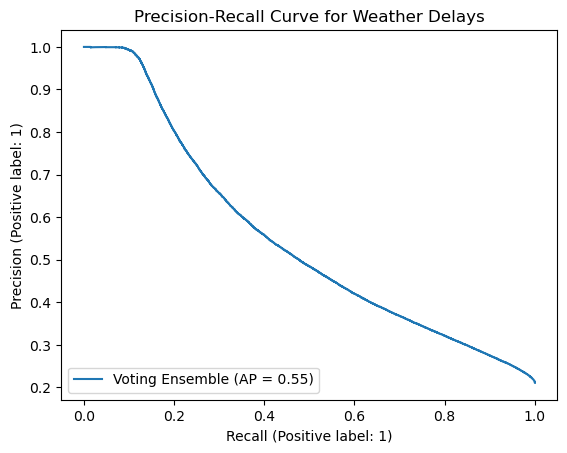

In [33]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob[:, 1], name="Voting Ensemble")
display.ax_.set_title("Precision-Recall Curve for Weather Delays")
plt.show()

In [47]:
final_pipeline.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num_features', StandardScaler(),
                                  Index(['DEP_HOUR', 'DISTANCE', 'WIND_DIR', 'WIND_SPD', 'WIND_GUST',
        'VISIBILITY', 'TEMPERATURE', 'DEW_POINT', 'REL_HUMIDITY', 'ALTIMETER',
        'LOWEST_CLOUD_LAYER', 'N_CLOUD_LAYER', 'LOW_LEVEL_CLOUD',
        'MID_LEVEL_CLOUD', 'HIGH_LEVEL_CLOUD', 'CLOUD_COVER', 'ACTIVE_WEATHER',
        'WEATHER_SEVERITY', 'TEMP_DEW_DIFF', 'WIND_INTENSITY', 'TOTAL_CLOUD',
        'CLOUD_COVER_ENCODED'],
       dtype='object')),
                                 ('cat_features',
                                  OneHotEncoder(handle_unknown='ignore'),
                                  Index(['DEST', 'HUMIDITY_LEVEL', 'ICAO TYPE', 'MANUFACTURER',
        'OP_UNIQUE_CARRIER', 'ORIGIN', 'RANGE', 'VISIBILITY_CATEGORY', 'WIDTH',
        'WIND_DIRECTION'],
       dtype='object'))]),
 'classifier': VotingClassifier(estimators=[('rf',
                               RandomForestClassi

In [55]:
print(list(final_pipeline.named_steps.keys()))

['preprocessor', 'classifier']


In [57]:
xgb_model = final_pipeline.named_steps['classifier'].estimators_[1]

feature_names = final_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = xgb_model.feature_importances_

In [59]:
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

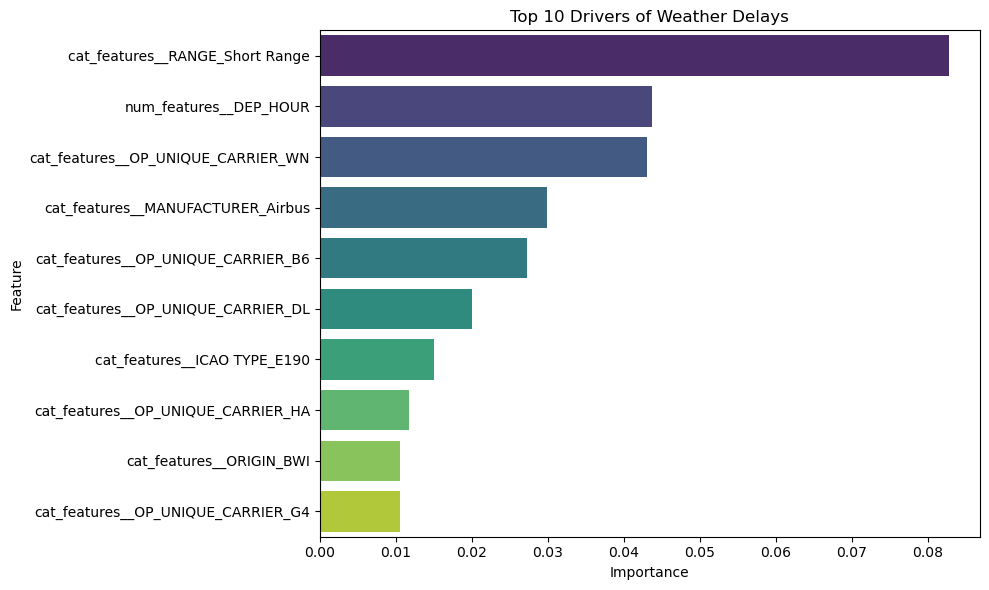

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Top 10 Drivers of Weather Delays")
plt.tight_layout()
plt.show()

In [63]:
print(X_train.columns.tolist())

['DEP_HOUR', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DISTANCE', 'MANUFACTURER', 'ICAO TYPE', 'RANGE', 'WIDTH', 'WIND_DIR', 'WIND_SPD', 'WIND_GUST', 'VISIBILITY', 'TEMPERATURE', 'DEW_POINT', 'REL_HUMIDITY', 'ALTIMETER', 'LOWEST_CLOUD_LAYER', 'N_CLOUD_LAYER', 'LOW_LEVEL_CLOUD', 'MID_LEVEL_CLOUD', 'HIGH_LEVEL_CLOUD', 'CLOUD_COVER', 'ACTIVE_WEATHER', 'WEATHER_SEVERITY', 'TEMP_DEW_DIFF', 'WIND_INTENSITY', 'VISIBILITY_CATEGORY', 'HUMIDITY_LEVEL', 'WIND_DIRECTION', 'TOTAL_CLOUD', 'CLOUD_COVER_ENCODED']
